# Stage 1.4.2.5.4
## Level 3 — Image Content Understanding & Semantic Extraction

Yes. Now we implement Level 3 — Image Content Understanding & Semantic Extraction as a real experiment.

The key change from Level 1/2 is:

        Level 1 → Is there a picture?
        Level 2 → Can I extract the picture?
        Level 3 → Can a vision model understand what is inside the picture?

Docling supports picture-description enrichment, where a vision-language model generates a textual description for a detected picture. The description is added to the DoclingDocument for accessibility/searchability.

For our architecture diagram, this is exactly the experiment we want.

#### Stage 1.4.2.5.4

#### Level 3 — Image Content Understanding & Semantic Extraction

Our experiment:

        Architecture Diagram
                ↓
        PictureItem
                ↓
        Picture Description / VLM
                ↓
        Semantic description
                ↓
        Searchable text
                ↓
        Potential RAG content
        
We will not use a separate OCR script first. We want to see what Docling's picture-understanding capability can do.

## Step 1 — Start with our existing PDF
Use the same PDF:

    docling_table_image_formula_sample.pdf
And verify:

In [11]:
from pathlib import Path

pdf_path = Path(
    "D:\\AI Learning\\rag-learning\\data\\raw\\pdf\\Stage 1.4.2.5.4-docling_table_image_formula_sample.pdf"
)

print(pdf_path.exists())

True


Expected:

True

## Step 2 — Verify your Docling version
Because you are using Docling 2.120.3, keep this in the notebook:

In [3]:
import docling

print(docling.__version__)

2.120.3


Expected:

2.120.3

This is important because Docling's enrichment APIs have evolved.

## Step 3 — Import the picture-description configuration
Run:

In [ ]:
# Docling imports
from docling.datamodel.pipeline_options import (
    PdfPipelineOptions,
    smolvlm_picture_description,
)

from docling.datamodel.base_models import InputFormat

from docling.document_converter import (
    DocumentConverter,
    PdfFormatOption,
)

Docling provides a preconfigured smolvlm_picture_description option for local picture description.

## Step 4 — Configure picture understanding
Create the pipeline:

In [13]:
pipeline_options = PdfPipelineOptions()

pipeline_options.generate_picture_images = True

pipeline_options.do_picture_description = True

pipeline_options.picture_description_options = (
    smolvlm_picture_description
)

Notice the important new line:

pipeline_options.do_picture_description = True

This is what moves us from:

    Level 2
    Picture extraction
to:

Level 3

Picture understanding

Docling's documentation describes do_picture_description as enabling automatic textual descriptions of pictures using vision-language models.

## Step 5 — Create the converter

In [14]:
converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(
            pipeline_options=pipeline_options
        )
    }
)

## Step 6 — Convert the PDF

In [16]:
result = converter.convert(pdf_path)

doc = result.document

This time the pipeline is doing considerably more work:

    PDF
    │
    ├── Layout analysis
    │
    ├── Table detection
    │
    ├── Picture detection
    │
    ├── Picture extraction
    │
    └── Picture description
              ↓
            VLM
So don't be surprised if this conversion takes longer than our previous one.

## Step 7 — Confirm that our picture still exists

In [17]:
print("Number of pictures:", len(doc.pictures))

Number of pictures: 1


Expected:

Number of pictures: 2

Why possibly two?

Our sample PDF contains:

        1. architecture diagram
        2. formula image

So Docling may detect both as pictures.

## Step 8 — Inspect the first picture


========== PICTURE 1 ==========
<class 'docling_core.types.doc.items.picture.picture.PictureItem'>
self_ref='#/pictures/0' parent=RefItem(cref='#/body') children=[RefItem(cref='#/texts/5'), RefItem(cref='#/texts/6'), RefItem(cref='#/texts/7'), RefItem(cref='#/texts/8'), RefItem(cref='#/texts/9')] content_layer=<ContentLayer.BODY: 'body'> meta=PictureMeta(summary=None, language=None, entities=None, keywords=None, topics=None, description=DescriptionMetaField(confidence=None, created_by='HuggingFaceTB/SmolVLM-256M-Instruct', text='In the image there is a diagram which is titled "Producer" and "Event Hubs" and both are connected with each other. "Producer" and "Event Hubs" are connected with "Stream Consumer" and "Stream Consumer" are connected with "Data Explorer" and "Data Explorer" are both connected with "Data Explorer" and "Data Explorer" are both connected with "Stream Consumer" and "Stream Consumer" are both connected with "Data Explorer" and "Data Explorer" are both connected wit
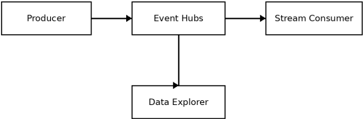

In [18]:
for i, picture in enumerate(doc.pictures, start=1):

    print(f"\n========== PICTURE {i} ==========")

    print(type(picture))

    print(picture)

We're looking for evidence that the picture now has enrichment information.

## Step 9 — Look specifically for the picture description
Let's inspect the picture object's attributes:

In [19]:
picture = doc.pictures[0]

attributes = [
    name
    for name in dir(picture)
    if not name.startswith("_")
]

print(attributes)

['annotations', 'caption_text', 'captions', 'children', 'comments', 'construct', 'content_layer', 'copy', 'dict', 'export_to_doctags', 'export_to_document_tokens', 'export_to_html', 'export_to_markdown', 'footnotes', 'from_orm', 'get_annotations', 'get_image', 'get_location_tokens', 'get_ref', 'image', 'json', 'label', 'meta', 'model_computed_fields', 'model_config', 'model_construct', 'model_copy', 'model_dump', 'model_dump_json', 'model_extra', 'model_fields', 'model_fields_set', 'model_json_schema', 'model_parametrized_name', 'model_post_init', 'model_rebuild', 'model_validate', 'model_validate_json', 'model_validate_strings', 'parent', 'parse_file', 'parse_obj', 'parse_raw', 'prov', 'references', 'schema', 'schema_json', 'self_ref', 'source', 'update_forward_refs', 'validate']


Look for attributes related to:

annotation
description
caption
prov
image
The exact representation can vary by Docling version, which is why we're inspecting your actual 2.120.3 object rather than assuming the current API shape.

## Step 10 — Inspect the picture annotations
Try:

In [20]:
print(
    getattr(
        picture,
        "annotations",
        None
    )
)

[DescriptionAnnotation(kind='description', text='In the image there is a diagram which is titled "Producer" and "Event Hubs" and both are connected with each other. "Producer" and "Event Hubs" are connected with "Stream Consumer" and "Stream Consumer" are connected with "Data Explorer" and "Data Explorer" are both connected with "Data Explorer" and "Data Explorer" are both connected with "Stream Consumer" and "Stream Consumer" are both connected with "Data Explorer" and "Data Explorer" are both connected with "Stream Consumer" and "Stream Consumer" are both connected with "Data Explorer" and "Data Explorer" are both connected with "Stream Consumer" and "Stream Consumer" are both connected with "Data Explorer" and "Data Explorer" are both connected with "Stream Consumer" and "Stream Consumer" are both connected with "Data Explorer" and "Data Explorer" are both connected with "Stream Consumer" and "Stream Consumer" are both connected with "Data Explorer"', provenance='HuggingFaceTB/SmolV

C:\Users\Siva Ponakala\AppData\Local\Temp\ipykernel_16364\1370730931.py:2: DeprecationWarning: Field `annotations` is deprecated; use `meta` instead.
  getattr(


If you get an object/list instead of None, inspect it:

In [21]:
annotations = getattr(
    picture,
    "annotations",
    None
)

print(type(annotations))

if annotations:
    for annotation in annotations:
        print(annotation)

<class 'list'>
kind='description' text='In the image there is a diagram which is titled "Producer" and "Event Hubs" and both are connected with each other. "Producer" and "Event Hubs" are connected with "Stream Consumer" and "Stream Consumer" are connected with "Data Explorer" and "Data Explorer" are both connected with "Data Explorer" and "Data Explorer" are both connected with "Stream Consumer" and "Stream Consumer" are both connected with "Data Explorer" and "Data Explorer" are both connected with "Stream Consumer" and "Stream Consumer" are both connected with "Data Explorer" and "Data Explorer" are both connected with "Stream Consumer" and "Stream Consumer" are both connected with "Data Explorer" and "Data Explorer" are both connected with "Stream Consumer" and "Stream Consumer" are both connected with "Data Explorer" and "Data Explorer" are both connected with "Stream Consumer" and "Stream Consumer" are both connected with "Data Explorer"' provenance='HuggingFaceTB/SmolVLM-256M-In

C:\Users\Siva Ponakala\AppData\Local\Temp\ipykernel_16364\2676054372.py:1: DeprecationWarning: Field `annotations` is deprecated; use `meta` instead.
  annotations = getattr(


This is where we expect to find the semantic description generated by the vision model.

## Step 11 — Inspect the complete picture object
For our learning experiment, I also want you to run:

{'self_ref': '#/pictures/0', 'parent': {'cref': '#/body'}, 'children': [{'cref': '#/texts/5'}, {'cref': '#/texts/6'}, {'cref': '#/texts/7'}, {'cref': '#/texts/8'}, {'cref': '#/texts/9'}], 'content_layer': <ContentLayer.BODY: 'body'>, 'meta': {'summary': None, 'language': None, 'entities': None, 'keywords': None, 'topics': None, 'description': {'confidence': None, 'created_by': 'HuggingFaceTB/SmolVLM-256M-Instruct', 'text': 'In the image there is a diagram which is titled "Producer" and "Event Hubs" and both are connected with each other. "Producer" and "Event Hubs" are connected with "Stream Consumer" and "Stream Consumer" are connected with "Data Explorer" and "Data Explorer" are both connected with "Data Explorer" and "Data Explorer" are both connected with "Stream Consumer" and "Stream Consumer" are both connected with "Data Explorer" and "Data Explorer" are both connected with "Stream Consumer" and "Stream Consumer" are both connected with "Data Explorer" and "Data Explorer" are bo
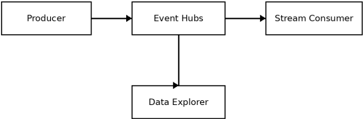

In [22]:
print(picture.model_dump())

Because DoclingDocument elements are Pydantic models in the current Docling architecture.

This gives us a much better picture of what Docling actually stored.

Look for anything resembling:

    annotations
    description
    text
    provenance

## Step 12 — Search the entire DoclingDocument
Now let's use the most important test.
We know the architecture contains:

    Producer
    Event Hubs
    Stream Consumer
    Data Explorer
Run:

In [23]:
architecture_words = [
    "Producer",
    "Event Hubs",
    "Stream Consumer",
    "Data Explorer",
]

Then:

In [24]:
markdown_text = doc.export_to_markdown()

print(markdown_text)

## Stage 1.4.2.5.4 - Docling Table / Image / Formula Understanding

This document is intentionally designed as a controlled test document for Docling. It contains ordinary text, a structured table, an embedded architecture image, and a mathematical formula.

## 1. Structured Table

|   Stage | Component           | Purpose                              |
|---------|---------------------|--------------------------------------|
|       1 | Event Producer      | Publishes business events            |
|       2 | Azure Event Hubs    | Ingests and partitions event streams |
|       3 | Stream Consumer     | Reads and transforms events          |
|       4 | Azure Data Explorer | Stores data for analytics            |

## 2. Architecture Image / Figure

## Event Processing Architecture

Figure 1 - Event processing architecture

<!-- image -->

In the image there is a diagram which is titled "Producer" and "Event Hubs" and both are connected with each other. "Producer" and "Event Hubs" are con

And:

In [25]:
print("\n========== ARCHITECTURE TEXT TEST ==========")

for word in architecture_words:

    found = word.lower() in markdown_text.lower()

    print(
        f"{word:20} -> "
        f"{'FOUND' if found else 'NOT FOUND'}"
    )


========== ARCHITECTURE TEXT TEST ==========
Producer             -> FOUND
Event Hubs           -> FOUND
Stream Consumer      -> FOUND
Data Explorer        -> FOUND


## Step 13 — This is the critical comparison
Before Level 3 we had something like:

    Architecture diagram detected     ✅
    Picture extracted                 ✅
    "Producer" in document text       ❌
    "Event Hubs" in document text     ❌

After picture-description enrichment, we're testing whether we get:

    Architecture diagram detected     ✅
    Picture extracted                 ✅
    Picture described by VLM          ✅
    Semantic information available    ✅
However, do not expect the VLM description to necessarily reproduce every label verbatim.

For example, it might produce:

"The diagram shows an event processing
architecture in which a producer sends
events to Event Hubs, which forwards
them to a stream consumer and ultimately
to Data Explorer."

That is semantic understanding, even if it doesn't return the exact four labels.

## Step 14 — Very important: OCR vs semantic understanding
This is where I want you to make an important distinction.
Suppose the picture description is:

    "An architecture diagram showing a producer sending events through Event Hubs to a stream consumer and Data Explorer."

That demonstrates:

    Image
    ↓
    Vision model
    ↓
    Meaning

But it does not necessarily prove exact OCR of every text label.
Compare:

#### OCR
    Producer
    Event Hubs
    Stream Consumer
    Data Explorer

#### Semantic description
    A producer sends events through
    Event Hubs to a stream consumer
    and then to Data Explorer.

These are different outputs.

Therefore our Level 3 is correctly called:

    Image Content Understanding & Semantic Extraction
    
rather than simply:

Image OCR.

## Step 15 — Make the experiment more rigorous
Let's inspect both the raw picture and the generated description.

In [ ]:
for i, picture in enumerate(doc.pictures, start=1):

    print("\n" + "=" * 70)
    print(f"PICTURE {i}")
    print("=" * 70)

    print("\nType:")
    print(type(picture))

    print("\nImage:")
    image = picture.get_image(doc)
    print(type(image))

    print("\nAnnotations:")
    print(
        getattr(
            picture,
            "annotations",
            None
        )
    )

This gives us a clean:
    
    Picture
    ├── actual image
    └── semantic annotation

## Step 16 — Inspect the complete document after enrichment
Now:

In [ ]:
markdown_text = doc.export_to_markdown()

print(markdown_text)

This is particularly important.

We're asking:

    Did the picture description become part of the document representation?

Docling's picture-description enrichment is specifically designed to add descriptions to the document for searchability/accessibility.

## Step 17 — Compare Level 2 vs Level 3
Your notebook should now document this very clearly.

#### Level 2

    PDF
    ↓
    Picture detection
    ↓
    PictureItem
    ↓
    Actual image

#### Level 3

    PDF
    ↓
    Picture detection
    ↓
    PictureItem
    ↓
    Actual image
    ↓
    Vision-Language Model
    ↓
    Picture description
    ↓
    Semantic text

And ultimately:

    Semantic text
        ↓
    Chunking
        ↓
    Embedding
        ↓
    Vector DB
        ↓
        RAG

## Step 18 — What happens to our architecture diagram?
Our original image:

    ┌─────────────────────────────────────────┐
    │       Event Processing Architecture     │
    │                                         │
    │ Producer → Event Hubs → Stream Consumer │
    │                    ↓                    │
    │              Data Explorer              │
    └─────────────────────────────────────────┘

can potentially become something like:

Event Processing Architecture

    A producer sends events to Azure Event Hubs.
    The events are consumed by a stream consumer
    and subsequently sent to Azure Data Explorer
    for analytics.

That textual representation is much more useful to a text-based RAG pipeline.

## Step 19 — Why this is important for your production RAG
Consider a user asking:

    "Where do the events go after Event Hubs?"
##### Without Level 3:

    PDF
    ↓
    Picture
    ↓
    Vector DB

The text RAG pipeline may not know what is inside the picture.

##### With Level 3:

    PDF
    ↓
    Picture
    ↓
    VLM
    ↓
    "Events are consumed by Stream Consumer
    and sent to Data Explorer."
    ↓
    Chunk
    ↓
    Embedding
    ↓
    ChromaDB
Now retrieval can potentially return the semantic information from the architecture diagram.

## Step 20 — One important caveat
For exact labels, diagrams, and technical architecture, a generic picture-description model may not be sufficient.

For example, the model could say:

        "A cloud architecture showing an event ingestion service and analytics service."
while missing:

        Azure Event Hubs
        Azure Data Explorer

Therefore production multimodal ingestion often combines:

                Image
                        │
                ┌───────┴────────┐
                ↓                ↓
        OCR              VLM
                │                │
        exact text          semantic meaning
                │                │
                └───────┬────────┘
                        ↓
                combined representation

This is an important lesson for your RAG journey:

        OCR gives you text; VLM gives you meaning; combining them can give you a richer representation.

##### Our Stage 1.4.2.5.4 progress
We can now structure the stage as:

Stage 1.4.2.5.4

        Docling Table / Image / Formula Understanding
        │
        ├── Level 1
        │   Picture Detection
        │   ✅
        │
        ├── Level 2
        │   Picture Extraction
        │   ✅
        │
        └── Level 3
        Image Content Understanding & Semantic Extraction
        🔵 CURRENT

And Level 3 itself is:

        Step 1
        Enable picture description
                ↓
        Step 2
        Run Docling conversion
                ↓
        Step 3
        Inspect PictureItem
                ↓
        Step 4
        Inspect picture annotations
                ↓
        Step 5
        Export Markdown
                ↓
        Step 6
        Verify semantic description
                ↓
        Step 7
        Compare OCR vs VLM understanding
                ↓
        Step 8
        Understand RAG implications

One note before you run it: because you're on Docling 2.120.3, if the `smolvlm_picture_description` import or the annotation fields differ in your environment, don't modify things randomly. Paste the exact error/output here. We'll adapt the implementation specifically to your installed version rather than silently using APIs from a newer Docling release.

In [26]:
architecture_words = [
    "Producer",
    "Event Hubs",
    "Stream Consumer",
    "Data Explorer",
]

print("========== DOCLING DOCUMENT ITEMS ==========")

for item, level in doc.iterate_items():

    text = getattr(item, "text", "")

    if text:

        for word in architecture_words:

            if word.lower() in text.lower():

                print(
                    f"\nFOUND: {word}"
                )

                print(
                    "Item type:",
                    type(item).__name__
                )

                print(
                    "Text:",
                    repr(text)
                )

========== DOCLING DOCUMENT ITEMS ==========


In [27]:
for i, picture in enumerate(doc.pictures, start=1):

    print(f"\n========== PICTURE {i} ==========")

    annotations = getattr(
        picture,
        "annotations",
        None
    )

    print("Annotations:")
    print(annotations)


========== PICTURE 1 ==========
Annotations:
[DescriptionAnnotation(kind='description', text='In the image there is a diagram which is titled "Producer" and "Event Hubs" and both are connected with each other. "Producer" and "Event Hubs" are connected with "Stream Consumer" and "Stream Consumer" are connected with "Data Explorer" and "Data Explorer" are both connected with "Data Explorer" and "Data Explorer" are both connected with "Stream Consumer" and "Stream Consumer" are both connected with "Data Explorer" and "Data Explorer" are both connected with "Stream Consumer" and "Stream Consumer" are both connected with "Data Explorer" and "Data Explorer" are both connected with "Stream Consumer" and "Stream Consumer" are both connected with "Data Explorer" and "Data Explorer" are both connected with "Stream Consumer" and "Stream Consumer" are both connected with "Data Explorer" and "Data Explorer" are both connected with "Stream Consumer" and "Stream Consumer" are both connected with "Da

C:\Users\Siva Ponakala\AppData\Local\Temp\ipykernel_16364\492382854.py:5: DeprecationWarning: Field `annotations` is deprecated; use `meta` instead.
  annotations = getattr(
